# Working with Tabular Data and Plotting 

<div class="alert alert-block alert-info">
<h2>Overview</h2>

Questions:

* What python libraries are used to analyze tabular data?

* How do you access rows and columns of data in numpy?

* What are the differences between lists and numpy arrays?

* What python libraries are available for plotting and data visualization?


Objectives:

* Read data in from CVS files into numpy arrays

* Access data in numpy arrays

* Use broadcasting to calculate quantities in numpy

* Make properly labeled graphical representations of data in python.


# Part 1: Working with Tabular Data using numpy

A commonly used python library for working so-called tabular data (data presented in rows and columns) is numerical python or numpy.  As with any python library, we begin by importing the library so we can use its function in our code.  

As with our lesson last week, the first step of our process will be to read in our data from an external file.  As we already discussed, there are many ways to read in data from files in python. In a previous lesson, we used the `readlines()` function to read in a complex output file. In theory, you could always use the `readlines()` function, and then use the data parsing tools we learned previously to format the data as you needed. But sometimes there are other ways that make more sense, particularly if the data is (1) all or mostly one type of data (for example, all numbers) and/or (2) formatted in a table. Frequently, a table will be mostly numbers, but have column or row labels.

A common file format for such tables is the CSV file or comma separated values. This is exactly what it sounds like. Data is presented in rows, with each value separated by a comma. If you have data in a spreadsheet program that you need to import into a python code, you can save the data as a csv file to read it in.

In this example, we have a CSV file that contains data from a molecular dynamics trajectory. We have a 20 ns simulation that used a 2 fs timestep. The data was saved to the trajectory file every 1000 steps, so our file has 10,000 timesteps. At each timestep, we are interested in the distance between particular atoms. These trajectories were generated with the AMBER molecular dynamics program and the distances were measured with the python program MDAnalysis. The table of atomic distances was saved as a CVS file called “distance_data_headers.csv”. This file is in your `data` folder that you cloned from GitHub.  You could open the file in a text editor and study it to determine its structure.

Since the data is uniform in structure and presented in a table, there is a better way to read it in than using `readlines`.  We will use a function from numpy called `genfromtxt` to read in the data.  The output of this function is a data structure called a numpy array, where the data is stored in rows and columns.  

In [1]:
# Import all required libraries for the lesson

import numpy
import matplotlib.pyplot as plt

## Reading in the data from the file

In [2]:
# Path to our CSV file
distance_file = '../data/distance_data_headers.csv'

# Read as unicode so headers and numbers can coexist
distances = numpy.genfromtxt(fname=distance_file, delimiter=',', dtype='unicode')

print(distances[:5])


[['Frame' 'THR4_ATP' 'THR4_ASP' 'TYR6_ATP' 'TYR6_ASP']
 ['1' '8.9542' '5.8024' '11.5478' '9.9557']
 ['2' '8.6181' '6.0942' '13.9594' '11.6945']
 ['3' '9.0066' '6.0637' '13.0924' '11.3043']
 ['4' '9.2002' '6.0227' '14.5282' '10.1763']]


### Separate headers from numeric data

In the file our first rows is the headers for our data table.  These are words or characters so the `str` data type.  The rest of our data is decimal numbers, so the `float` data type.  We need to seperate our data using the slicing strategies we learned previously so that we can recast the data as the correct type.

In [3]:
headers = distances[0]
# Doesn't need to be recast; already strings
print(headers)

['Frame' 'THR4_ATP' 'THR4_ASP' 'TYR6_ATP' 'TYR6_ASP']


<div class="alert alert-block alert-warning"> 
<strong>Check your understanding</strong>
    
Take a slice of the array that contains *only* the numerical values (all rows except the headers). Save it in a variable called `data`.

</div>

In [4]:
# Your code goes here


In [5]:
data = distances[1:]
#Print a few rows just to check
print(data[:3])

[['1' '8.9542' '5.8024' '11.5478' '9.9557']
 ['2' '8.6181' '6.0942' '13.9594' '11.6945']
 ['3' '9.0066' '6.0637' '13.0924' '11.3043']]


### Convert strings to floats with `astype`

Even though we now have just the numbers, the numbers are all still strings. We know this because (1) we read them all in as unicode and (2) if we look at the output of the print statement, we can see that each number is enclosed in single quotes, indicating that it is a string. We need to recast these values as floats. The numpy library has a built-in function to accomplish this. In this case, keeping a variable with all the same information as strings is not useful to us, so this is a case where we are going to overwrite our variable data.

In [6]:
data = data.astype(float)
print(data[:3])


[[ 1.      8.9542  5.8024 11.5478  9.9557]
 [ 2.      8.6181  6.0942 13.9594 11.6945]
 [ 3.      9.0066  6.0637 13.0924 11.3043]]


## Indexing and slicing 2D arrays

The basic indexing pattern is:

`array_name[row, column]`

Slicing uses the same idea, but with ranges:

`array_name[row_start:row_stop, col_start:col_stop]`


<div class="alert alert-block alert-warning"> 
<strong>Check your understanding</strong>
    
Consider the two variables shown below.  **Think** about what you think this will be and then use a print statement to check your answer.

</div>

In [7]:
point1 = data[0, 1]
point2 = data[1, 0]

In [8]:
print(F'Point1 is {point1}.')
print(F'Point2 is {point2}.')

Point1 is 8.9542.
Point2 is 2.0.


### Slicing arrays

There you can also take two-dimensional slices of an array where you specify a range of rows and a range of columns for the slice. For example, sometimes it is easier to work with a small subset of our data for testing rather than the full data set. This command takes a slice that includes only the first ten rows and the first three columns of our data.  As with the slicing syntax we learned before, if you do not include a starting index, it automatically starts at zero.  If you do not include an ending index, it automatically goes to the end.

In [9]:
small_data = data[0:10, 0:3]
print(small_data)


[[ 1.      8.9542  5.8024]
 [ 2.      8.6181  6.0942]
 [ 3.      9.0066  6.0637]
 [ 4.      9.2002  6.0227]
 [ 5.      9.1294  5.9365]
 [ 6.      9.0462  6.2553]
 [ 7.      8.8657  5.9186]
 [ 8.      9.3256  6.2351]
 [ 9.      9.4184  6.1993]
 [10.      9.06    6.0478]]


<div class="alert alert-block alert-warning"> 
<strong>Check your understanding</strong>
    
Consider the two slices shown below.  **Think** about what you think these two slices will be and then use a print statement to check your answer.

</div>

In [10]:
array1 = small_data[5, :]
array2 = small_data[:, 1:]

In [11]:
print(small_data[5, :])
print(small_data[:, 1:])


[6.     9.0462 6.2553]
[[8.9542 5.8024]
 [8.6181 6.0942]
 [9.0066 6.0637]
 [9.2002 6.0227]
 [9.1294 5.9365]
 [9.0462 6.2553]
 [8.8657 5.9186]
 [9.3256 6.2351]
 [9.4184 6.1993]
 [9.06   6.0478]]


## Analyzing tabular data 

The numpy library has numerous built-in functions. For example, to calculate the average (mean) of a data set, the syntax is

`data_average = numpy.mean(data_set)`

Let’s say we want to calculate the average distance for a particular measurement over the whole simulation; that is, we want to calculate the average of one of the columns. We can take a slice of our data array that is just one column. Then we can find the average of that column. It doesn’t make sense to average the frame numbers, so let’s do the THR4_ATP column first.



In [12]:
thr4_atp = data[:, 1]  # every row, THR4_ATP column
avg_thr4_atp = numpy.mean(thr4_atp)
print(avg_thr4_atp)


10.876950930000001


### Looping over columns with `range()`

This is correct, but now we would like to calculate the average of every column. This seems like a job for a `for` loop, but unlike last time, we don’t want to count over a particular list and do something for every item, we want to do something a particular number of times. Basically, we want to take that 1 and let it be every number, up to the number of columns. This is a task for the `range()` function. The general syntax is

`range(start,end)`

and we can use range() in a for loop.

In our example, the “end” value needs to be the number of columns of data.



<div class="alert alert-block alert-warning"> 
<strong>Check your understanding</strong>
    
Determine the number of columns in `data`. Save it to `num_columns`.

Hint: the number of columns is the length of any row.  Think about how to use slicing syntax to pull out one row of the table and measure its length.

</div>

In [13]:
# Your code goes here


In [14]:
# The number of columns is the length of any row
# I will use slicing syntax to pull out the first row 
num_columns = len(data[0, :])
print(num_columns)

5


In [15]:
# Now I can set up a for loop to calculate the average of every column
for i in range(1, num_columns):
    column = data[:, i]
    avg_col = numpy.mean(column)
    print(f'{headers[i]} : {avg_col}')


THR4_ATP : 10.876950930000001
THR4_ASP : 7.342344959999999
TYR6_ATP : 11.209791329999998
TYR6_ASP : 10.9934435


### Lists vs. Numpy Arrays

Lists and numpy arrays have many similarities, including the syntax of indexing and slicing. However, numpy arrays have some features that python lists do not. 

In [16]:
# This is a list 
number_list = [1, 2, 3, 5, 7, 11]

# If I wanted to multiple each element by 2, you might think you would do this
number_list2 = number_list * 2

#But this doesn't given what I expected
print(number_list2)

[1, 2, 3, 5, 7, 11, 1, 2, 3, 5, 7, 11]


If you want to do this using skills you already know, you would have to use a `for` loop, convert each element and save the values to a new list

In [17]:
number_list2 = []
for num in number_list:
    times2 = num*2
    number_list2.append(times2)

print(number_list2)

[2, 4, 6, 10, 14, 22]


This is actually much easier in numpy and eliminates the need for the `for` loop.  While for our purposes this usually doesn't matter, this would also make your code much faster.

In [18]:
# Recast the list to a numpy array
number_array = numpy.asarray(number_list)

# Now this does work and makes a new numpy array
number_array2 = number_array*2
print(number_array2)

[ 2  4  6 10 14 22]


Numpy arrays also have many other features, including the ability to do vector math.  

In [19]:
vector1 = numpy.asarray([7, 2, 5])
vector2 = numpy.asarray([1, 1, 3])
difference_vector = vector1 - vector2
print(f'Difference vector: {difference_vector}')
product_vector = vector1*vector2
print(f'Product vector: {product_vector}')
dot_product = numpy.dot(vector1, vector2)
print(f'The dot product of vector1 and vector2: {dot_product}')

Difference vector: [6 1 2]
Product vector: [ 7  2 15]
The dot product of vector1 and vector2: 24


# Part 2: Graphing using matplotlib



## Import abbreviations 

We know that, in general, when we call a function from a python library the syntax is `library_name.function_name`.  If the `library_name` is long, then you can abbreviate it at the time of import.  If you look back up at the import cell at the top of this notebook, you will see that this is what we did.  For some python libraries there are particular abbreviations that are commonly used.   `matplotlib.pyplot` is commonly imported as `plt`.

## Making a basic plot


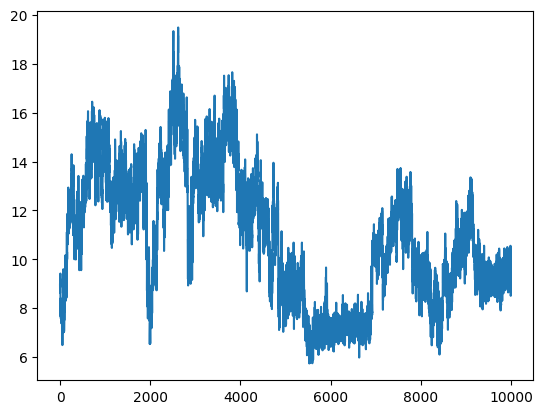

In [20]:
plt.figure()  # initialize a new figure

# Plot one column of data; if you only specify one column (y-values), it plots the numbers in the order they are given
plt.plot(data[:, 1]) 
plt.show()


## Labeling plots and saving figures

Add:

- x-axis label (`xlabel`)
- y-axis label (`ylabel`)
- a legend (`legend`) using `label=` in `plot`
- save to a file (`savefig`)


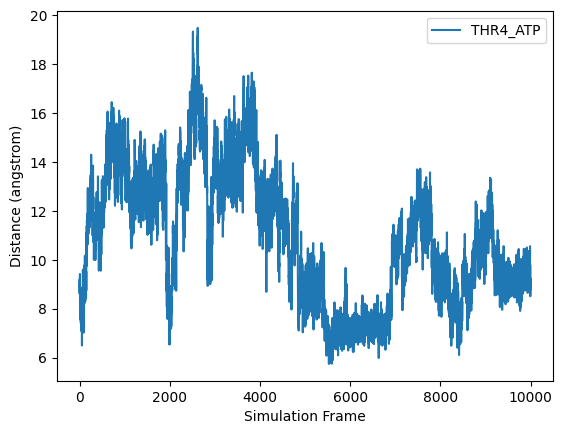

Saved: THR4_ATP.png


In [21]:
plt.figure()
plt.xlabel('Simulation Frame')
plt.ylabel('Distance (angstrom)')
plt.plot(data[:, 1], label=headers[1])
plt.legend()

plt.savefig(f'{headers[1]}.png')
plt.show()

print('Saved:', f'{headers[1]}.png')


## Increasing image resolution

Add `dpi=300` to save at higher resolution (common for publications or presentations).

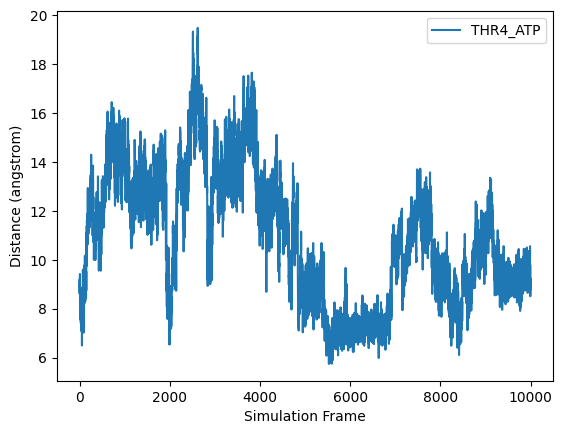

In [22]:
plt.figure()
plt.xlabel('Simulation Frame')
plt.ylabel('Distance (angstrom)')
plt.plot(data[:, 1], label=headers[1])
plt.legend()

plt.savefig(f'{headers[1]}_dpi300.png', dpi=300)
plt.show()


## Plotting more than one dataset

Just add additional `plot` calls.  You can also customize each plot with different colors.


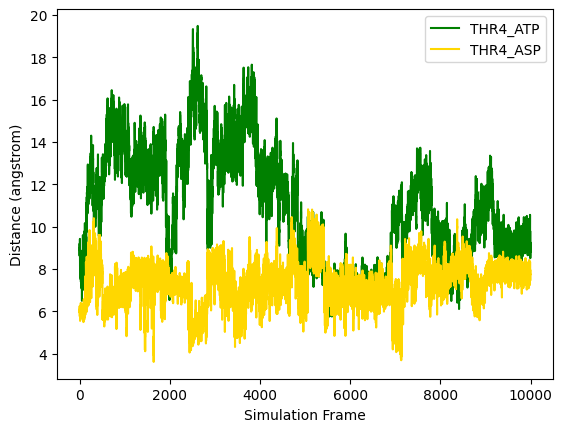

Saved: two_samples.png


In [23]:
plt.figure()
plt.xlabel('Simulation Frame')
plt.ylabel('Distance (angstrom)')
plt.plot(data[:, 1], label=headers[1], color='green')
plt.plot(data[:, 2], label=headers[2], color='gold')
plt.legend()

plt.savefig('two_samples.png')
plt.show()

print('Saved: two_samples.png')


Python knows a lot of colors, but if you really want to really customize your colors, you can use color hexcodes.  For example, you can look up the official Cal Poly green and gold hexcodes on the [university marketing website](https://ucm.calpoly.edu/color-guidelines).

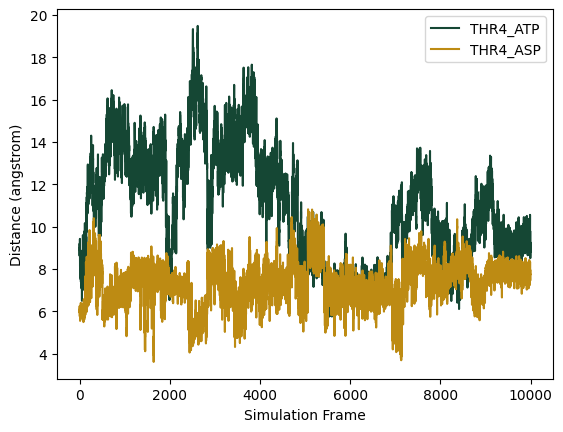

In [24]:
plt.figure()
plt.xlabel('Simulation Frame')
plt.ylabel('Distance (angstrom)')
plt.plot(data[:, 1], label=headers[1], color='#154734')
plt.plot(data[:, 2], label=headers[2], color='#BD8B13')
plt.legend()

plt.savefig('cal_poly_colors.png')
plt.show()


<div class="alert alert-block alert-warning"> 
<strong>Check your understanding</strong>
    
Rather than copying and pasting the line of code and replacing the column number for each different data set, you could also use the range for loop we learned about above to plot all the data sets on one graph.  Use a range for loop to plot all the data sets on one graph and save it as a file called 'all_samples.png'.

</div>

In [25]:
# Your code goes here

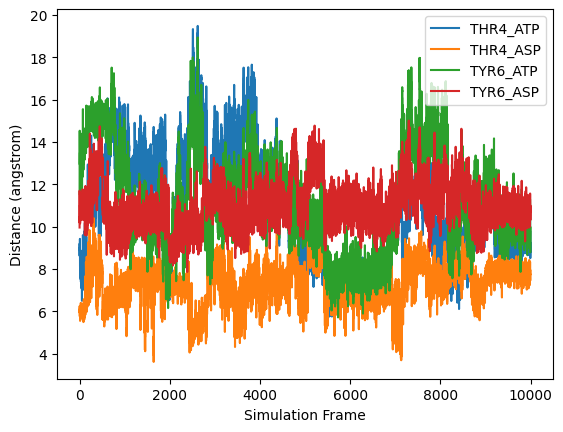

Saved: all_samples.png


In [26]:
plt.figure()

for col in range(1, len(headers)):
    plt.plot(data[:, col], label=headers[col])

plt.xlabel('Simulation Frame')
plt.ylabel('Distance (angstrom)')
plt.legend()

plt.savefig('all_samples.png')
plt.show()

print('Saved: all_samples.png')


<div class="alert alert-block alert-warning"> 
<strong>Check your understanding</strong>
    
Make a **different plot for each sample** and save each image with filename `sample_name.png`.

Hint: You can modify your code from the previous code block.  The key is to think about what goes inside the for loop and what goes outside the for loop.
</div>


In [27]:
# Your code goes here


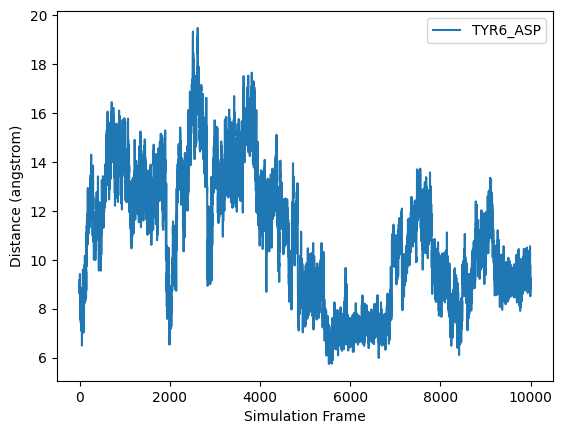

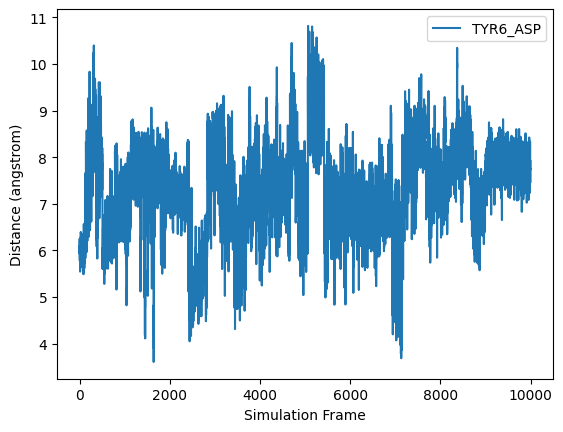

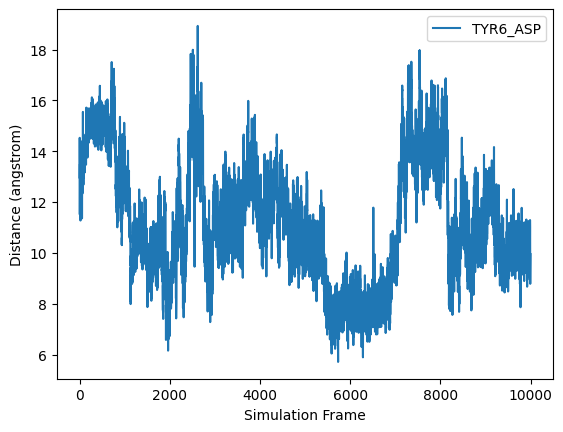

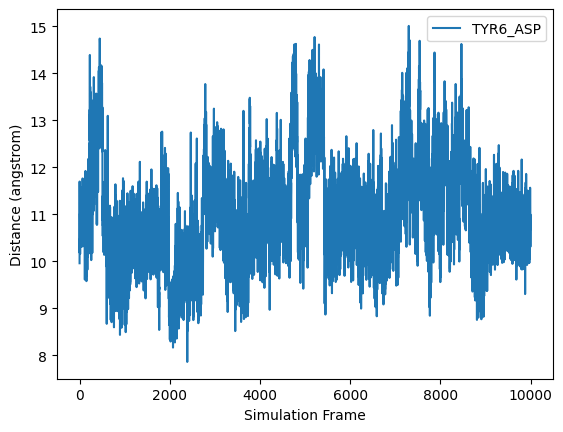

In [28]:
# The key is to move the plt.figure() command the the save command in the for loop
for col in range(1, len(headers)):
    plt.figure()
    sample = headers[col]

    plt.plot(data[:, col], label=headers[i])
    plt.legend()
    plt.xlabel('Simulation Frame')
    plt.ylabel('Distance (angstrom)')

    plt.savefig(f'{headers[i]}.png')
    plt.show()

### Normalizing axes across plots

If you were actually going to display these four graphs together on a poster presentation, for example, you would probably want to set all the y-axis limits to the same value.  

You can set this with the command `plt.ylim(min_value, max_value)`.


In [29]:
# Copy and paste code block from above and modify
# Decide on good values for y_min and y_max from looking at graphs above


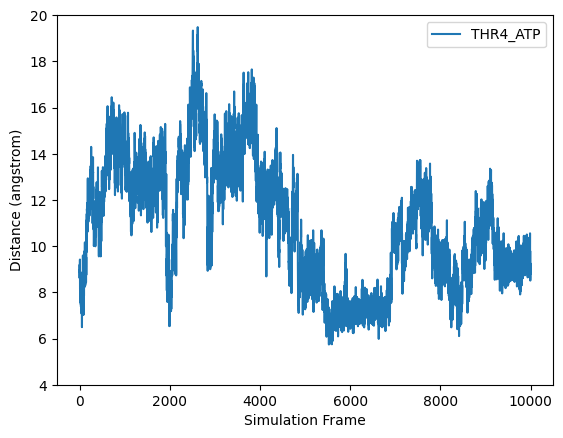

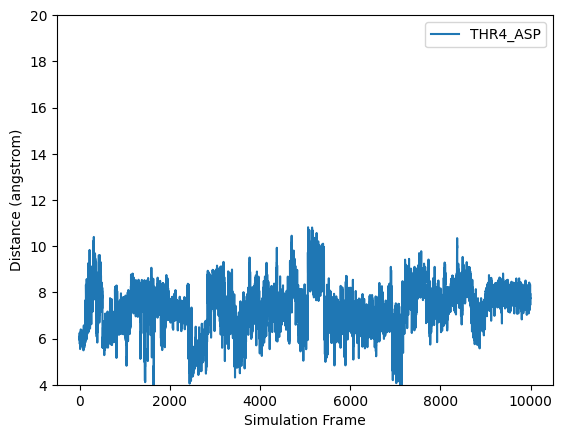

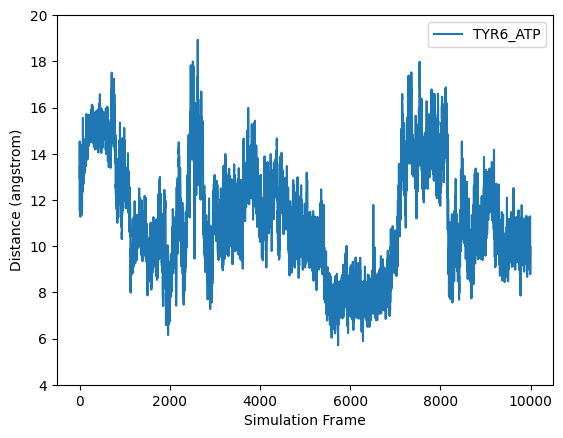

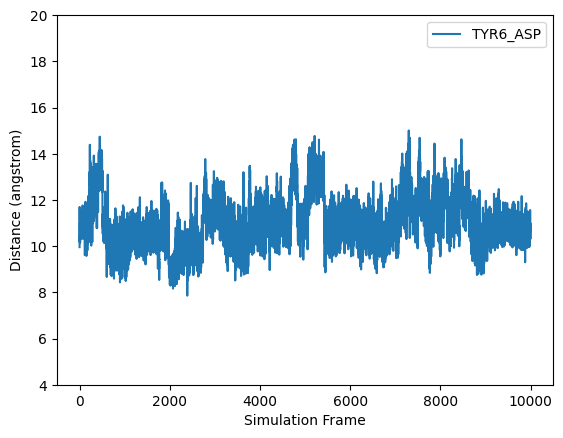

In [30]:
y_min = 4
y_max = 20

for col in range(1, len(headers)):
    plt.figure()
    sample = headers[col]

    plt.plot(data[:, col], label=sample)
    plt.ylim(y_min, y_max)    #this is the new line
    plt.legend()
    plt.xlabel('Simulation Frame')
    plt.ylabel('Distance (angstrom)')

    plt.show()

## Plotting with `x` and `y`

If `plot` gets only one argument, it treats it as `y` and uses the index as `x`.

To plot (x,y) data, the syntax is `plt.plot(x_data, ydata)

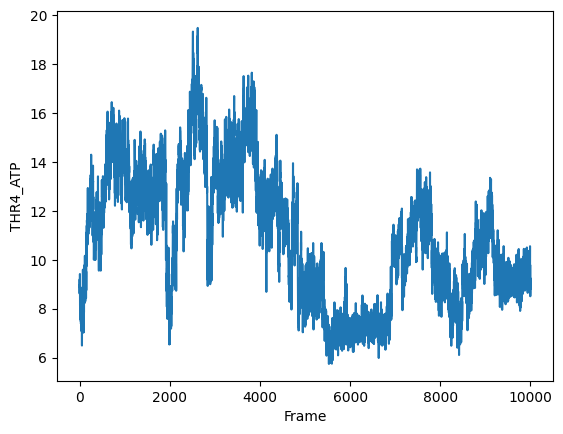

In [31]:
# Plot the frame number as x and the first column of data as y
plt.figure()
plt.plot(data[:, 0], data[:, 1])
plt.xlabel('Frame')
plt.ylabel(headers[1])
plt.show()


## Final Activity 

For your final activity last week, you created a file called `Etot.txt` with the energies you parsed from the molecular dynamics output file.  Read that file in as a numpy array.  Remove the last two data points from your array; these are not actually simluation data points, one is the average energy over the whole simulation and the other is the RMS fluctuation.  

Plot the energy over the course of the simulation using matplotlib.  Look up the hexcode for a color you like and use that for your plot color.

302


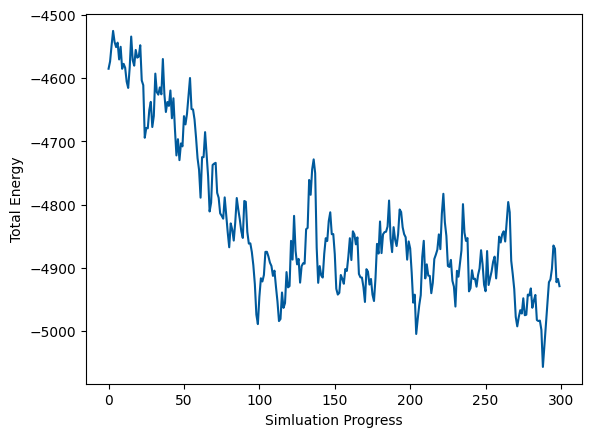

In [32]:
data_file = '../data/Etot.txt'
data = numpy.genfromtxt(fname=data_file)
#How many points are in your data
num_points = len(data)
print(num_points)

# Plot the data
plt.plot(data[0:num_points - 2], color='#005A9C')
plt.ylabel("Total Energy")
plt.xlabel('Simluation Progress')
plt.show()

In [34]:
#This is the code cell that makes the student version
# Go to Edit --> Clear Outputs of all cells
# Save the notebook
# Change the file name in the nbconvert line to the relevant thing
# Fill in the output filename with the student-version-filename
# Run this cell
# This cell is itself deleted in the student notebook
!jupyter nbconvert instructor-key.ipynb  --to notebook \
    --TagRemovePreprocessor.enabled=True \
    --ClearOutputPreprocessor.enabled=True \
    --TagRemovePreprocessor.remove_cell_tags=\[\"solution\"\] \
    --output student.ipynb

/Users/armcdona/anaconda3/lib/python3.11/site-packages/traitlets/traitlets.py:2915: FutureWarning: --TagRemovePreprocessor.remove_cell_tags=["solution"] for containers is deprecated in traitlets 5.0. You can pass `--TagRemovePreprocessor.remove_cell_tags item` ... multiple times to add items to a list.
  warn(
[NbConvertApp] Converting notebook instructor-key.ipynb to notebook
[NbConvertApp] Writing 23353 bytes to student.ipynb
